# 7.  Investigate extreme cases 

1. Reproduce example presented during the lecture (drug survey). 

In [1]:
import arviz as az
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 46 seconds.


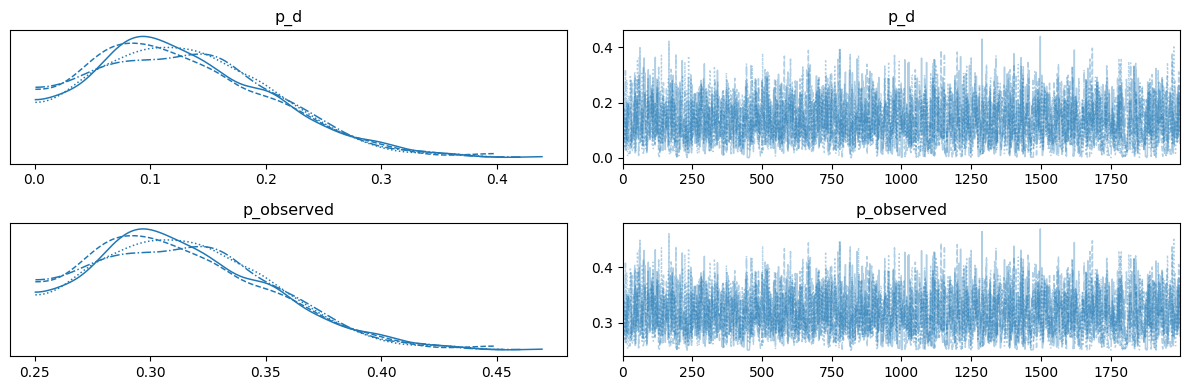

In [7]:
with pm.Model() as model:
    p_d = pm.Uniform("p_d", 0, 1)
    p_observed = pm.Deterministic("p_observed", 0.25 + 0.5 * p_d)
    
    ## Bernoulli distribution 
    occurences = np.concatenate((np.ones(30),np.zeros(70)))
    answers = pm.Bernoulli("answers", p_observed, observed = occurences)
    
    ## Binomial distribution
    # yes_count = 30
    # answers = pm.Binomial("answers", 100, p_observed, p_observed=yes_count)
    
    idata = pm.sample(2000, tune=2500)
    
az.plot_trace(idata)
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 32 seconds.


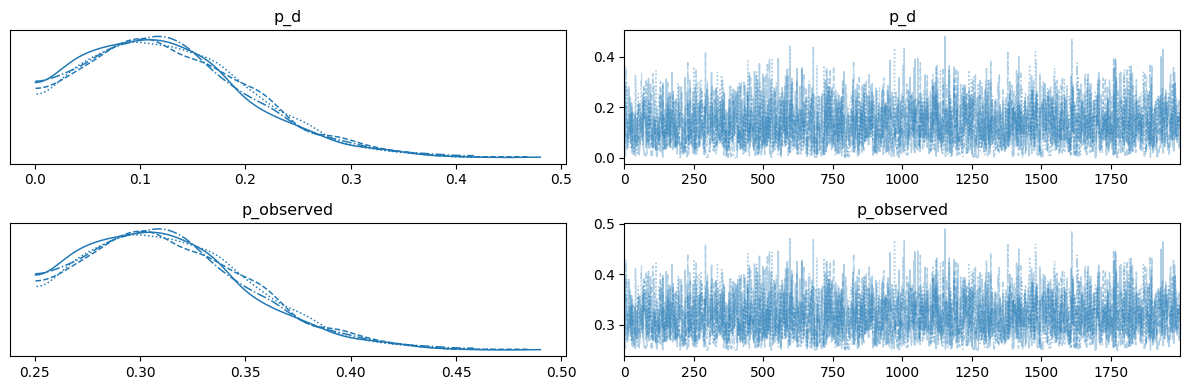

In [10]:
with pm.Model() as model:
    p_d = pm.Uniform("p_d", 0, 1)
    p_observed = pm.Deterministic("p_observed", 0.25 + 0.5 * p_d)
    
    ## Bernoulli distribution 
    # occurences = np.concatenate((np.ones(30),np.zeros(70)))
    # answers = pm.Bernoulli("answers", p_observed, observed = occurences)
    
    ## Binomial distribution
    yes_count = 30
    answers = pm.Binomial("answers", 100, p_observed, observed=yes_count)
    
    idata = pm.sample(2000, tune=2500)
    
az.plot_trace(idata)
plt.tight_layout()
plt.show()

2. See what happens when the number of “yes” answers (out of 100) is 

    a. 20 

    b. 10 

    c. 5 
    
Explain.

a) 20 yes answers

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 53 seconds.


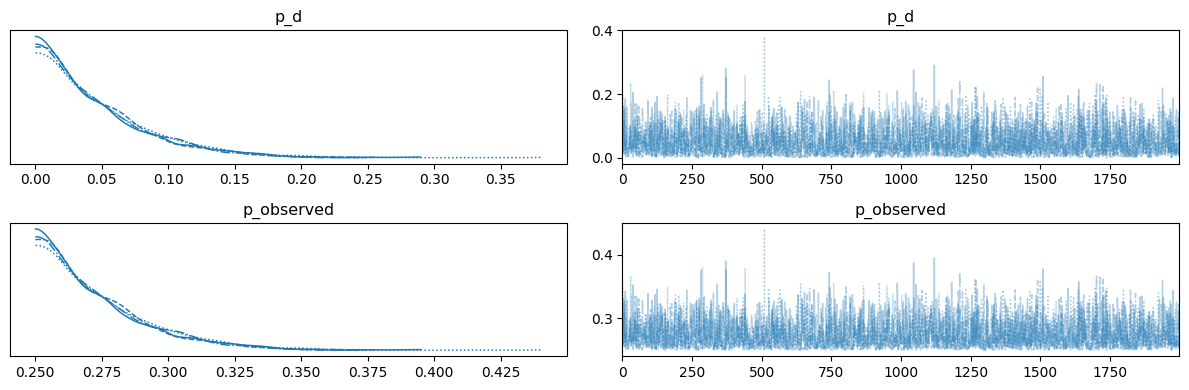

In [9]:
with pm.Model() as model:
    p_d = pm.Uniform("p_d", 0, 1)
    p_observed = pm.Deterministic("p_observed", 0.25 + 0.5 * p_d)
    
    ## Bernoulli distribution 
    occurences = np.concatenate((np.ones(20),np.zeros(80)))
    answers = pm.Bernoulli("answers", p_observed, observed = occurences)
    
    idata = pm.sample(2000, tune=2500)
    
az.plot_trace(idata)
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 18 seconds.


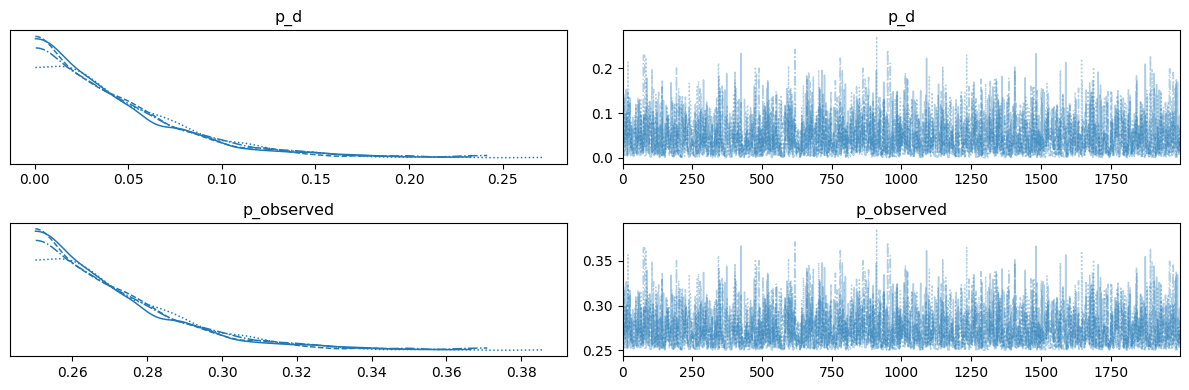

In [11]:
with pm.Model() as model:
    p_d = pm.Uniform("p_d", 0, 1)
    p_observed = pm.Deterministic("p_observed", 0.25 + 0.5 * p_d)
    
    ## Binomial distribution
    yes_count = 20
    answers = pm.Binomial("answers", 100, p_observed, observed=yes_count)
    
    idata = pm.sample(2000, tune=2500)
    
az.plot_trace(idata)
plt.tight_layout()
plt.show()

b) 10 yes answers

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 41 seconds.


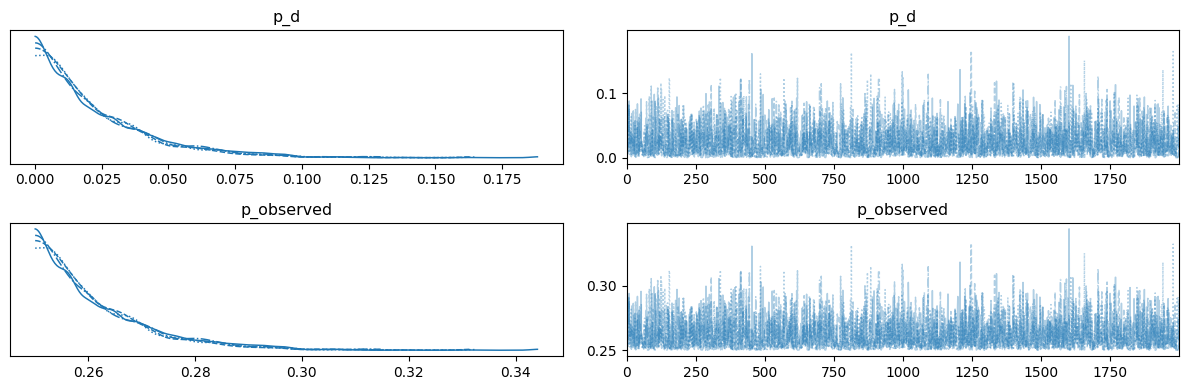

In [14]:
with pm.Model() as model:
    p_d = pm.Uniform("p_d", 0, 1)
    p_observed = pm.Deterministic("p_observed", 0.25 + 0.5 * p_d)
    
    ## Bernoulli distribution 
    occurences = np.concatenate((np.ones(10),np.zeros(90)))
    answers = pm.Bernoulli("answers", p_observed, observed = occurences)
    
    idata = pm.sample(2000, tune=2500)
    
az.plot_trace(idata)
plt.tight_layout()
plt.show()

c) 5 yes answers

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 22 seconds.


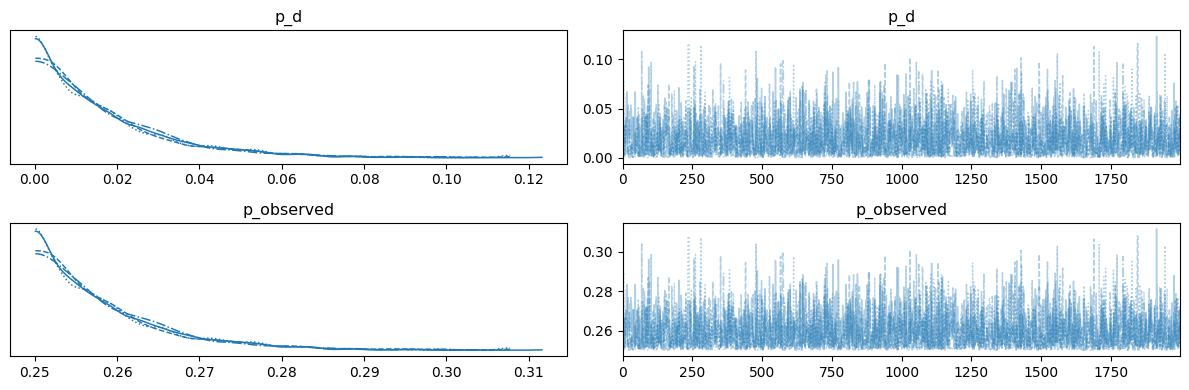

In [15]:
with pm.Model() as model:
    p_d = pm.Uniform("p_d", 0, 1)
    p_observed = pm.Deterministic("p_observed", 0.25 + 0.5 * p_d)
    
    ## Bernoulli distribution 
    occurences = np.concatenate((np.ones(5),np.zeros(95)))
    answers = pm.Bernoulli("answers", p_observed, observed = occurences)
    
    idata = pm.sample(2000, tune=2500)
    
az.plot_trace(idata)
plt.tight_layout()
plt.show()

Looking at the plots, we can observe that when the number of positive answers dropped below 20, the probability that someone actually uses drugs oscillates around zero.

\begin{equation}
p(Y) = \frac{1}{2}(\frac{1}{2} * 1 + \frac{1}{2} * 0) + \frac{1}{2}p_d = \frac{1}{4} + \frac{1}{2}p_d
\end{equation}

Looking at the formula, we can better visualize this - even if nobody uses drugs, the probability of flipping tails twice and answering "yes" is 25%. The observed p_observed is statistically highly improbable, since randomness alone guarantees at least 25% "yes" answers. This is either due to a too small sample size or falsified results.

# 8.  Generate sample data 

1. Modify previous example in order to obtain a sample datasets: 


    a. Generate a set of 100 answers for probability of a randomly chosen student taking 
    drugs equal to: 0.1; 0.5; 0.9 


    b. Set the probability of a randomly chosen student taking drugs at 0.1, count of the 
    group at 100. The survey was repeated 50 times, generate number of “yes” answers 
    for each attempt. 

In [24]:
p_d = 0.1
p_observed = 0.25 + 0.5 * p_d 

answers_a = np.random.binomial(1, p_observed, size=100)
print(f"a) yes answers: {answers_a.sum()}")

p_d = 0.5
p_observed = 0.25 + 0.5 * p_d 
answers_b = np.random.binomial(1, p_observed, size=100)
print(f"b) yes answers: {answers_b.sum()}")

p_d = 0.9
p_observed = 0.25 + 0.5 * p_d 
answers_c = np.random.binomial(1, p_observed, size=100)
print(f"c) yes answers: {answers_c.sum()}")

a) yes answers: 24
b) yes answers: 54
c) yes answers: 75


In [ ]:
p_d = 0.1
p_observed = 0.25 + 0.5 * p_d 
n = 100 # number of tries in one survey
size = 50 # how many repeat the generation of survey

answers = np.random.binomial(100, p_observed, size=50)

answers

array([32, 28, 34, 32, 27, 20, 40, 33, 30, 36, 32, 31, 25, 35, 26, 20, 24,
       37, 28, 33, 25, 27, 28, 40, 32, 27, 32, 33, 24, 26, 37, 25, 34, 30,
       37, 22, 30, 27, 32, 30, 36, 24, 26, 38, 30, 31, 24, 24, 26, 30],
      dtype=int32)